# Curated Excel Figures in Python

This notebook is rebuilt from `plot_data_curated.xlsx`. The Excel file is no longer required to draw the figures because raw values are embedded below. Two plot types are supported: `condition_compare` for Mooney/Normal within Left/Right, and `ff_fb_compare` for feedforward/feedback within Mooney/Normal. Error bars are computed from raw values at runtime. Change `ERROR_MODE = "sem"` to `"std"` if you want standard deviation instead of SEM.

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MOONEY_COLOR = '#f0c808'
NORMAL_COLOR = '#e07a5f'
LINE_COLOR = '#8a8a8a'
ERROR_MODE = 'sem'  # 'sem' or 'std'
SAVE_FIGURES = False
FIGURE_DIR = Path('curated_plot_outputs')
FIGURE_DIR.mkdir(exist_ok=True)


def summarize(raw, mode=ERROR_MODE):
    values = np.asarray(raw, dtype=float)
    values = values[np.isfinite(values)]
    mean = float(np.mean(values)) if len(values) else np.nan
    if len(values) <= 1:
        error = np.nan
    elif mode == 'std':
        error = float(np.std(values, ddof=1))
    else:
        error = float(np.std(values, ddof=1) / np.sqrt(len(values)))
    return mean, error


def condition_color(condition):
    return MOONEY_COLOR if condition.lower().startswith('mooney') else NORMAL_COLOR


def chart_to_dataframe(chart):
    rows = []
    for item in chart['data']:
        mean, error = summarize(item['raw'])
        row = dict(item)
        row['mean'] = mean
        row['error'] = error
        row['n'] = len(item['raw'])
        rows.append(row)
    return pd.DataFrame(rows)


def _paired_x(center, n, spread):
    if n <= 1:
        return np.array([center]) if n == 1 else np.array([])
    return center + np.linspace(-spread, spread, n)


def _draw_subject_points(ax, x, raw, color, filled=True, zorder=5):
    raw = np.asarray(raw, dtype=float)
    xs = _paired_x(x, len(raw), 0.035)
    ax.scatter(xs, raw, s=16, facecolors=color if filled else 'white', edgecolors='black', linewidths=0.45, alpha=0.82, zorder=zorder)
    return xs


def plot_condition_compare(chart, figsize=(4.4, 3.4), connect_paired=True, show_data=False):
    df = chart_to_dataframe(chart)
    categories = list(dict.fromkeys(df['category']))
    conditions = ['Mooney', 'Normal']
    x = np.arange(len(categories), dtype=float)
    width = 0.24
    offsets = {'Mooney': -width / 1.8, 'Normal': width / 1.8}
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    point_pos = {}
    for j, category in enumerate(categories):
        for condition in conditions:
            row = df[(df['category'] == category) & (df['condition'] == condition)].iloc[0]
            xpos = x[j] + offsets[condition]
            color = condition_color(condition)
            ax.bar(xpos, row['mean'], width=width, color=color, edgecolor=color, linewidth=0.9, zorder=2, label=condition if j == 0 else None)
            if np.isfinite(row['error']):
                ax.errorbar(xpos, row['mean'], yerr=row['error'], fmt='none', ecolor='black', elinewidth=1.2, capsize=3, capthick=1.2, zorder=6)
            xs = _draw_subject_points(ax, xpos, row['raw'], color, filled=True)
            point_pos[(category, condition)] = (xs, np.asarray(row['raw'], dtype=float))
    if connect_paired:
        for category in categories:
            xs_a, raw_a = point_pos[(category, 'Mooney')]
            xs_b, raw_b = point_pos[(category, 'Normal')]
            n = min(len(raw_a), len(raw_b), len(xs_a), len(xs_b))
            for k in range(n):
                ax.plot([xs_a[k], xs_b[k]], [raw_a[k], raw_b[k]], color=LINE_COLOR, alpha=0.45, linewidth=0.75, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, fontsize=10)
    ax.set_ylabel(chart.get('ylabel', 'Value'))
    ax.set_title(chart.get('title', ''), fontsize=10, pad=8)
    _finish_axes(fig, ax, chart)
    #ax.legend(frameon=False, fontsize=8)
    if SAVE_FIGURES:
        _save_figure(fig, chart)
    if show_data:
        display(df)
    return fig, ax, df


def plot_ff_fb_compare(chart, figsize=(4.4, 3.4), connect_paired=True, show_data=False):
    df = chart_to_dataframe(chart)
    conditions = ['Mooney', 'Normal']
    directions = ['V1/OFA -> FFA', 'FFA/OFA -> V1']
    x = np.arange(len(conditions), dtype=float)
    width = 0.24
    offsets = {directions[0]: -width / 1.8, directions[1]: width / 1.8}
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    point_pos = {}
    for j, condition in enumerate(conditions):
        for direction in directions:
            row = df[(df['condition'] == condition) & (df['direction'] == direction)].iloc[0]
            xpos = x[j] + offsets[direction]
            color = condition_color(condition)
            is_feedback = row.get('style') == 'feedback'
            ax.bar(xpos, row['mean'], width=width, facecolor='white' if is_feedback else color, edgecolor=color, linewidth=2.4 if is_feedback else 0.9, zorder=2, label=direction if j == 0 else None)
            if np.isfinite(row['error']):
                ax.errorbar(xpos, row['mean'], yerr=row['error'], fmt='none', ecolor='black', elinewidth=1.2, capsize=3, capthick=1.2, zorder=6)
            xs = _draw_subject_points(ax, xpos, row['raw'], color, filled=not is_feedback)
            point_pos[(condition, direction)] = (xs, np.asarray(row['raw'], dtype=float))
    if connect_paired:
        for condition in conditions:
            xs_a, raw_a = point_pos[(condition, directions[0])]
            xs_b, raw_b = point_pos[(condition, directions[1])]
            n = min(len(raw_a), len(raw_b), len(xs_a), len(xs_b))
            for k in range(n):
                ax.plot([xs_a[k], xs_b[k]], [raw_a[k], raw_b[k]], color=LINE_COLOR, alpha=0.45, linewidth=0.75, zorder=3)
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, fontsize=10)
    ax.set_ylabel(chart.get('ylabel', 'Value'))
    ax.set_title(chart.get('title', ''), fontsize=10, pad=8)
    _finish_axes(fig, ax, chart)
    #ax.legend(frameon=False, fontsize=8)
    if SAVE_FIGURES:
        _save_figure(fig, chart)
    if show_data:
        display(df)
    return fig, ax, df


def plot_chart(chart, **kwargs):
    if chart['plot_kind'] == 'condition_compare':
        return plot_condition_compare(chart, **kwargs)
    if chart['plot_kind'] == 'ff_fb_compare':
        return plot_ff_fb_compare(chart, **kwargs)
    raise ValueError(f"Unknown plot kind: {chart['plot_kind']}")


def _finish_axes(fig, ax, chart=None):
    ax.axhline(0, color='#555555', linewidth=0.8, zorder=1)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)

    if chart is not None:
        yticks = chart.get('yticks')
        if yticks is not None:
            ax.set_yticks(yticks)
        ylim = chart.get('ylim')
        if ylim is not None:
            ax.set_ylim(ylim)
        elif yticks is not None and len(yticks) >= 2:
            step = yticks[1] - yticks[0]
            ax.set_ylim(min(yticks), max(yticks) + 0.05 * step)

    fig.tight_layout()


def _save_figure(fig, chart):
    safe = re.sub(r'[^A-Za-z0-9_\-]+', '_', chart.get('title', 'figure'))
    fig.savefig(FIGURE_DIR / f'{safe}.png', dpi=300, bbox_inches='tight')


## Figures

Run the first code cell once, then run any figure cell. Each `chart` dictionary contains the raw values used for that figure.

### Figure 01: Synergy peak intensity 0.1-0.2 s
Raw values embedded: 84

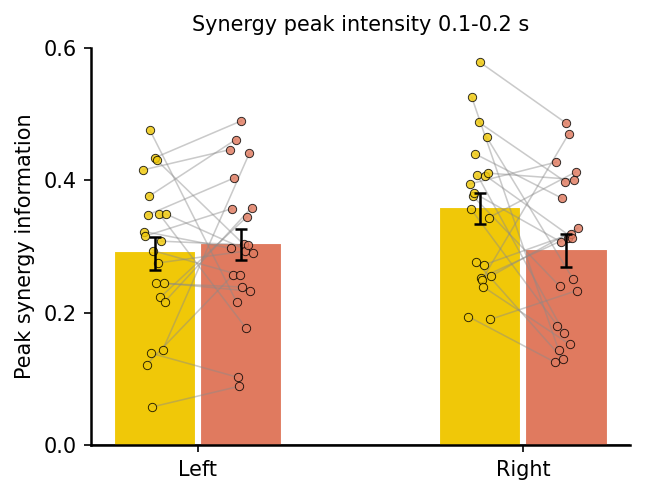

In [2]:
chart = {'plot_kind': 'condition_compare', 'title': 'Synergy peak intensity 0.1-0.2 s', 'ylabel': 'Peak synergy information', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.415627262957864, 0.322603178046495, 0.315902621228147, 0.122015219877965, 0.347663664287037, 0.375721381946477, 0.475270443092929, 0.139051652275938, 0.0580957639807883, 0.293682204861135, 0.433791356866334, 0.244638914513794, 0.430067605325651, 0.275253152080348, 0.349346221055217, 0.223351226232013, 0.308100276337809, 0.143589982013305, 0.244993968635325, 0.216970969433482, 0.349073201514462]}, {'category': 'Left', 'condition': 'Normal', 'raw': [0.446176571706034, 0.297268655141137, 0.357303653589833, 0.257819020963258, 0.403618699497325, 0.461203481399075, 0.215852368074069, 0.102758556342408, 0.0891642378295214, 0.256862172906463, 0.48955766737262, 0.239015717049513, 0.303456106080527, 0.293003426111043, 0.177265199913521, 0.344922390212006, 0.30225839038825, 0.440360164984906, 0.232710620330135, 0.358581594766941, 0.29063290692949]}, {'category': 'Right', 'condition': 'Mooney', 'raw': [0.194305496400982, 0.39425911807568, 0.357153957286003, 0.525157154513238, 0.37609953557896, 0.380681627879092, 0.439671443748063, 0.276992273440127, 0.407366651886277, 0.487657219993541, 0.578204535772175, 0.252780082548716, 0.249936293024059, 0.239345225293636, 0.272600782405908, 0.40702690718111, 0.465191256407242, 0.410795792307555, 0.343624956283016, 0.190002249357619, 0.255583201416377]}, {'category': 'Right', 'condition': 'Normal', 'raw': [0.125344334472477, 0.427327126721715, 0.180771371617447, 0.144005330302866, 0.240223852961368, 0.307000936998817, 0.372888792187205, 0.129961215110523, 0.169533584845716, 0.397779961425408, 0.485722389446926, 0.313119322066986, 0.470156374951495, 0.152302914051016, 0.319068179735822, 0.313475650066536, 0.250410659955603, 0.401120139378104, 0.412459966397445, 0.233477808310051, 0.328014256725831]}], 'yticks': [0.0, 0.2, 0.4, 0.6], 'ylim': [0.0, 0.6]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 02: Synergy peak latency 0.1-0.2 s
Raw values embedded: 84

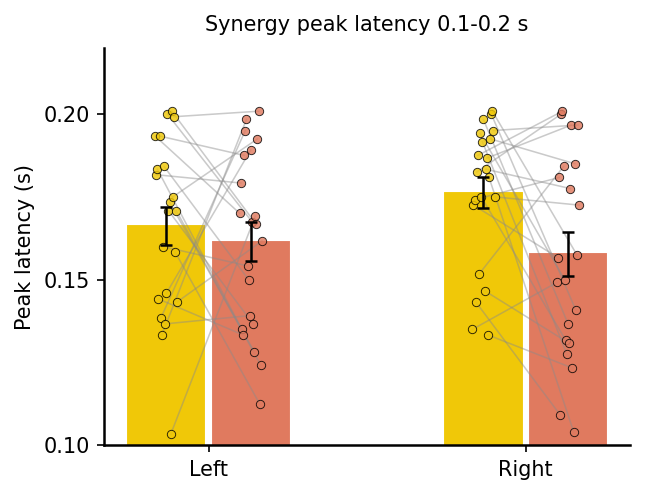

In [3]:
chart = {'plot_kind': 'condition_compare', 'title': 'Synergy peak latency 0.1-0.2 s', 'ylabel': 'Peak latency (s)', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.193333333333333, 0.181666666666666, 0.183333333333333, 0.144166666666667, 0.193333333333333, 0.138333333333333, 0.133333333333333, 0.16, 0.184166666666666, 0.136666666666667, 0.145833333333333, 0.2, 0.170833333333333, 0.173333333333333, 0.103333333333333, 0.200833333333333, 0.175, 0.199166666666667, 0.158333333333333, 0.170833333333333, 0.143333333333333]}, {'category': 'Left', 'condition': 'Normal', 'raw': [0.17, 0.179166666666666, 0.135, 0.133333333333333, 0.1875, 0.195, 0.198333333333333, 0.154166666666667, 0.15, 0.139166666666666, 0.189166666666666, 0.1675, 0.136666666666667, 0.128333333333333, 0.169166666666666, 0.166666666666667, 0.1925, 0.200833333333333, 0.1125, 0.124166666666667, 0.161666666666666]}, {'category': 'Right', 'condition': 'Mooney', 'raw': [0.135, 0.1725, 0.174166666666666, 0.143333333333333, 0.1825, 0.1875, 0.151666666666666, 0.194166666666666, 0.175, 0.191666666666666, 0.198333333333333, 0.146666666666667, 0.183333333333333, 0.186666666666667, 0.133333333333333, 0.180833333333333, 0.1925, 0.2, 0.200833333333333, 0.195, 0.175]}, {'category': 'Right', 'condition': 'Normal', 'raw': [0.149166666666666, 0.156666666666667, 0.180833333333333, 0.109166666666666, 0.2, 0.200833333333333, 0.184166666666666, 0.15, 0.131666666666666, 0.1275, 0.136666666666667, 0.130833333333333, 0.1775, 0.196666666666667, 0.123333333333333, 0.104166666666667, 0.185, 0.140833333333333, 0.1575, 0.196666666666667, 0.1725]}], 'yticks': [0.1, 0.15, 0.2], 'ylim': [0.1, 0.22]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 03: Synergy FF vs FB 0.1-0.2 s (Left)
Raw values embedded: 84

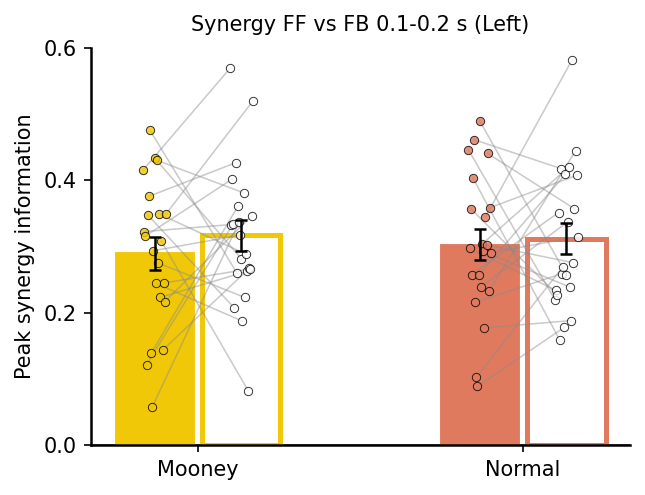

In [4]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Synergy FF vs FB 0.1-0.2 s (Left)', 'ylabel': 'Peak synergy information', 'hemisphere': 'Left', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.415627262957864, 0.322603178046495, 0.315902621228147, 0.122015219877965, 0.347663664287037, 0.375721381946477, 0.475270443092929, 0.139051652275938, 0.0580957639807883, 0.293682204861135, 0.433791356866334, 0.244638914513794, 0.430067605325651, 0.275253152080348, 0.349346221055217, 0.223351226232013, 0.308100276337809, 0.143589982013305, 0.244993968635325, 0.216970969433482, 0.349073201514462]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.56863059341889, 0.333133701766454, 0.401759774213911, 0.334538512688804, 0.207055758933602, 0.426326227810459, 0.260483933385378, 0.360645905805649, 0.336568487637455, 0.31724573619928, 0.2816162391988, 0.187389173287741, 0.381065530371479, 0.223281477082088, 0.288557869850344, 0.262579552555495, 0.0827380887475691, 0.267054264878646, 0.266491014296441, 0.346086767771683, 0.519129516055609]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.446176571706034, 0.297268655141137, 0.357303653589833, 0.257819020963258, 0.403618699497325, 0.461203481399075, 0.215852368074069, 0.102758556342408, 0.0891642378295214, 0.256862172906463, 0.48955766737262, 0.239015717049513, 0.303456106080527, 0.293003426111043, 0.177265199913521, 0.344922390212006, 0.30225839038825, 0.440360164984906, 0.232710620330135, 0.358581594766941, 0.29063290692949]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.219503276145042, 0.233714681706056, 0.226909455449268, 0.351192652658972, 0.159198865398856, 0.417705904807834, 0.259156715031158, 0.269834449759098, 0.177959702242439, 0.408943109606515, 0.257223174999588, 0.337216811850946, 0.419949745158201, 0.238756968539048, 0.188306054282814, 0.581916054781605, 0.275639032729632, 0.35702092961852, 0.444494159414054, 0.407602396829112, 0.314998713940808]}], 'yticks': [0.0, 0.2, 0.4, 0.6], 'ylim': [0.0, 0.6]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 04: Synergy FF vs FB 0.1-0.2 s (Right)
Raw values embedded: 84

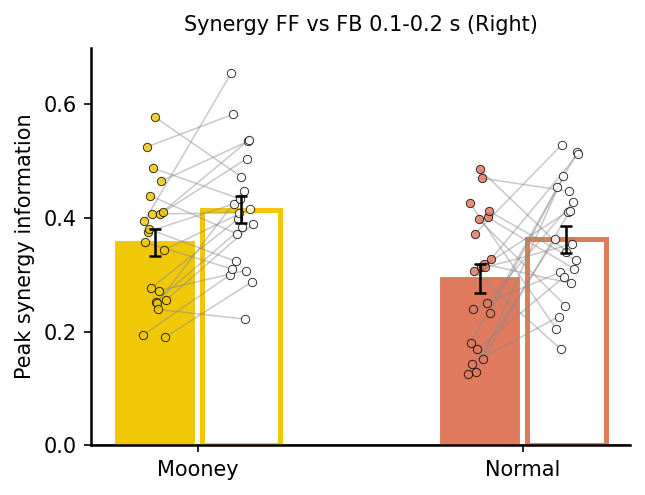

In [5]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Synergy FF vs FB 0.1-0.2 s (Right)', 'ylabel': 'Peak synergy information', 'hemisphere': 'Right', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.194305496400982, 0.39425911807568, 0.357153957286003, 0.525157154513238, 0.37609953557896, 0.380681627879092, 0.439671443748063, 0.276992273440127, 0.407366651886277, 0.487657219993541, 0.578204535772175, 0.252780082548716, 0.249936293024059, 0.239345225293636, 0.272600782405908, 0.40702690718111, 0.465191256407242, 0.410795792307555, 0.343624956283016, 0.190002249357619, 0.255583201416377]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.299928204176673, 0.654665791411555, 0.310272895977135, 0.582849051307037, 0.425418514310846, 0.32404298136618, 0.372490707476048, 0.398360102622514, 0.409323830854035, 0.433691121409852, 0.472789053480689, 0.384047942735761, 0.448542783836453, 0.222408280211845, 0.307764588503535, 0.504937541436657, 0.53520801380962, 0.538040963499625, 0.416935431209408, 0.2875081776576, 0.389228751664664]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.125344334472477, 0.427327126721715, 0.180771371617447, 0.144005330302866, 0.240223852961368, 0.307000936998817, 0.372888792187205, 0.129961215110523, 0.169533584845716, 0.397779961425408, 0.485722389446926, 0.313119322066986, 0.470156374951495, 0.152302914051016, 0.319068179735822, 0.313475650066536, 0.250410659955603, 0.401120139378104, 0.412459966397445, 0.233477808310051, 0.328014256725831]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.362580066025735, 0.204878182693669, 0.454336358707889, 0.226326403538586, 0.304538549189323, 0.16922471713497, 0.529403214489648, 0.473532700614576, 0.296704556056355, 0.246160746996143, 0.340150546698694, 0.411178108810747, 0.447271517165825, 0.412918036875417, 0.285094429987536, 0.354438346317177, 0.429048442662871, 0.310591404222511, 0.325439322926206, 0.515566018551434, 0.512094826608772]}], 'yticks': [0.0, 0.2, 0.4, 0.6], 'ylim': [0.0, 0.7]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 05: Synergy peak intensity 0.5-1.0 s
Raw values embedded: 84

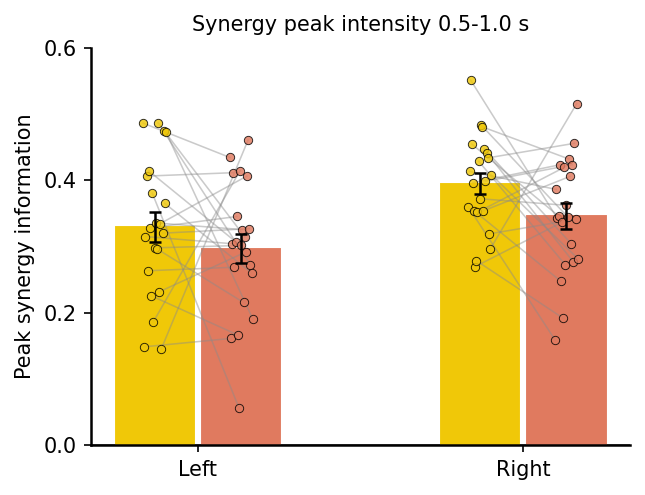

In [6]:
chart = {'plot_kind': 'condition_compare', 'title': 'Synergy peak intensity 0.5-1.0 s', 'ylabel': 'Peak synergy information', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.486121714826394, 0.148763071536921, 0.315119374422849, 0.406265047274673, 0.263456587056597, 0.413978713401709, 0.328049076582965, 0.225797233529221, 0.380392258611603, 0.186645197396102, 0.298041621502636, 0.33565659116988, 0.296624030766731, 0.486826858594567, 0.231619592176715, 0.334625334655749, 0.1459340824553, 0.320159515786087, 0.473888487296998, 0.365007361270787, 0.472574941292936]}, {'category': 'Left', 'condition': 'Normal', 'raw': [0.434331374865965, 0.161435596233496, 0.304227827464481, 0.411428124147579, 0.268808697425429, 0.307349236325682, 0.345336985252133, 0.166515122365156, 0.0564805940318688, 0.414592916618737, 0.301657459704758, 0.325546022630346, 0.215593565940339, 0.314795882264863, 0.291822042947408, 0.406397437953957, 0.460793113988852, 0.32690933462925, 0.272469469785487, 0.260164605258978, 0.191192378192912]}, {'category': 'Right', 'condition': 'Mooney', 'raw': [0.359565565197792, 0.413406837605679, 0.55104540614745, 0.454578044777841, 0.396285726759018, 0.3538646105756, 0.269778607631336, 0.278669693332277, 0.351746996951427, 0.428776519525286, 0.372134610186097, 0.483636429046804, 0.480669999400563, 0.353740083876168, 0.447492574046885, 0.3984685531978, 0.441703732961627, 0.433692268742941, 0.319073351004958, 0.295747162504359, 0.408522612710047]}, {'category': 'Right', 'condition': 'Normal', 'raw': [0.15900712996646, 0.386147241168549, 0.342406215015772, 0.346026321262252, 0.423312561179266, 0.247721580731763, 0.336499485490797, 0.19197357558043, 0.419398431702006, 0.272478648998543, 0.362180656102867, 0.344858242718271, 0.43218802310055, 0.405744842239555, 0.304531334809092, 0.423343730959099, 0.276969065194747, 0.455702411571037, 0.340988744487292, 0.515622489085966, 0.281818520798637]}], 'yticks': [0.0, 0.2, 0.4, 0.6], 'ylim': [0.0, 0.6]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 06: Synergy peak latency 0.5-1.0 s
Raw values embedded: 84

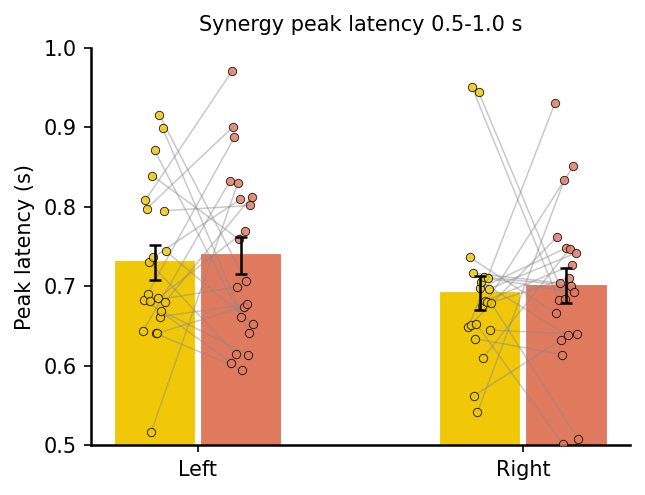

In [7]:
chart = {'plot_kind': 'condition_compare', 'title': 'Synergy peak latency 0.5-1.0 s', 'ylabel': 'Peak latency (s)', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.644166666666667, 0.683333333333333, 0.808333333333333, 0.7975, 0.690833333333333, 0.730833333333333, 0.681666666666666, 0.516666666666666, 0.839166666666667, 0.736666666666667, 0.870833333333333, 0.640833333333333, 0.640833333333333, 0.685, 0.915833333333333, 0.661666666666666, 0.669166666666667, 0.899166666666667, 0.795, 0.68, 0.744166666666666]}, {'category': 'Left', 'condition': 'Normal', 'raw': [0.8325, 0.604166666666667, 0.970833333333333, 0.900833333333333, 0.8875, 0.615, 0.699166666666667, 0.83, 0.759166666666667, 0.809166666666667, 0.661666666666666, 0.595, 0.674166666666667, 0.769166666666667, 0.706666666666667, 0.6775, 0.614166666666667, 0.641666666666667, 0.801666666666667, 0.8125, 0.6525]}, {'category': 'Right', 'condition': 'Mooney', 'raw': [0.648333333333333, 0.736666666666667, 0.651666666666666, 0.950833333333333, 0.716666666666667, 0.5625, 0.634166666666667, 0.6525, 0.541666666666667, 0.944166666666667, 0.6975, 0.705833333333333, 0.675833333333333, 0.61, 0.711666666666666, 0.681666666666666, 0.680833333333333, 0.71, 0.696666666666667, 0.645, 0.679166666666667]}, {'category': 'Right', 'condition': 'Normal', 'raw': [0.930833333333333, 0.665833333333333, 0.7625, 0.683333333333333, 0.704166666666667, 0.6325, 0.614166666666667, 0.501666666666667, 0.833333333333333, 0.684166666666667, 0.748333333333333, 0.638333333333333, 0.710833333333333, 0.7475, 0.700833333333333, 0.726666666666667, 0.850833333333333, 0.6925, 0.741666666666667, 0.64, 0.508333333333333]}], 'yticks': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0], 'ylim': [0.5, 1.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 07: Redundant FF vs FB 0.1-0.2 s (Left)
Raw values embedded: 84

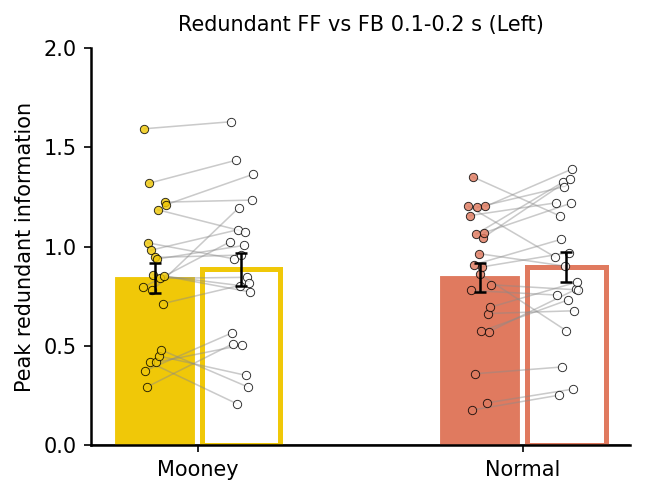

In [30]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Redundant FF vs FB 0.1-0.2 s (Left)', 'ylabel': 'Peak redundant information', 'hemisphere': 'Left', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.7952540546557124, 1.592244018292548, 0.3757962089136049, 0.29302054536312455, 1.018785713469752, 1.3182311272305929, 0.4169828443992152, 0.9820941344824957, 0.7789989913353098, 0.8581804399542922, 0.9451160085735166, 0.41716233031385774, 0.9369111877157822, 1.1845233880528965, 0.44911927790324335, 0.8400621765148106, 0.4799092680325244, 0.7125839313293236, 0.852494251254616, 1.2232551386425063, 1.210117950578955]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [1.0233242740077397, 1.627571976693004, 0.5661053979611247, 0.5122514450362323, 0.9376752648085441, 1.433366793047124, 0.20989573949396692, 1.0843970341771656, 1.19577988501891, 0.8036536370126344, 0.9572346681764146, 0.5047869334077885, 1.0053192127258401, 1.0743782441153003, 0.35239708619489307, 0.8452682468872219, 0.2933758093462415, 0.8155736219346068, 0.7712042825894218, 1.2336103947164818, 1.3625975161146273]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [1.2026104098415453, 1.1555981797676211, 0.7793423425877514, 0.17747846633011416, 1.3499671781212113, 0.9088295507363111, 0.3604570990482029, 1.0633367303253167, 1.1975533753499878, 0.9645490772539722, 0.8616468512379533, 0.5730237647718673, 0.897587182818569, 1.0450455817362125, 1.0695991109106502, 1.201467801944162, 0.21354938322119596, 0.6632998798065735, 0.5717005558480077, 0.6946092264572221, 0.8077216601261502]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.9471237247617894, 1.220044994371221, 0.7557965275380528, 0.2520993196314086, 1.154368403916659, 1.0357281470025514, 0.394402140876763, 1.3243269427284314, 1.3009175371710129, 0.9013153151900338, 0.5761537786757516, 0.7308620637546541, 0.9696356249698488, 1.3391810386634955, 1.2180012376881233, 1.3898752049260283, 0.28344027238009795, 0.6770799060372483, 0.7840180844324975, 0.8208405587467293, 0.781995169826441]}], 'yticks': [0.0, 0.5,1.0,1.5,2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 08: Redundant FF vs FB 0.1-0.2 s (Right)
Raw values embedded: 84

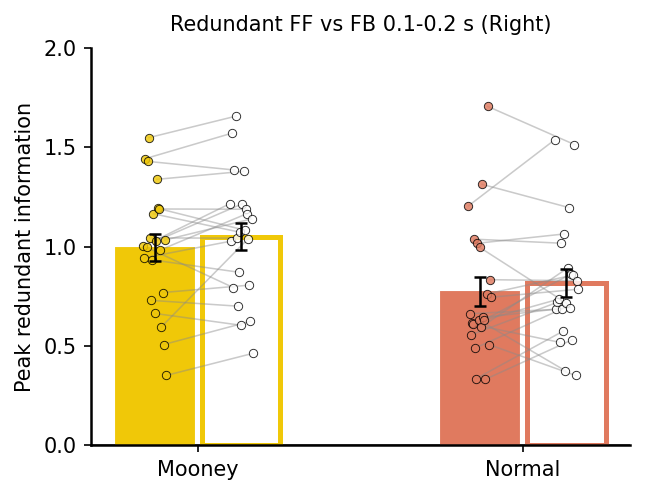

In [28]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Redundant FF vs FB 0.1-0.2 s (Right)', 'ylabel': 'Peak redundant information', 'hemisphere': 'Right', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [1.001221701771628, 0.9430917641000768, 1.4421998277283816, 0.9961382259404278, 1.4282690515014984, 1.5475521123620974, 1.0434946218207786, 0.7293520018206339, 0.9330510404473543, 1.1647550944438738, 0.6638786493470894, 1.0273114217122556, 1.337961774298083, 1.1916398666937646, 1.1888836648594774, 0.9827448328797068, 0.5961943807125258, 0.7686481157893712, 0.5071644079424118, 1.0327972554896103, 0.3516431803172666]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [1.2156437952627162, 1.0272004740500376, 1.5703784790949156, 0.7937440294017655, 1.384880210190328, 1.6552542627479445, 1.042121964684977, 0.7001548340406979, 0.8706776217662747, 1.0717978455992156, 0.6039311393821704, 1.215307415129467, 1.3781487889354873, 1.0823736759670486, 1.1874739568709878, 1.165437840324124, 1.0392769112661098, 0.8058361393168715, 0.6238787233281591, 1.1387350777521805, 0.46252716343304306]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [1.2041712312146196, 0.6621914451780441, 0.555363784640173, 0.6130916278216637, 0.6085631010909451, 1.0371216977565345, 0.48958663915421885, 0.3364650184362597, 1.016571676374845, 0.6309945101795926, 0.99557051328261, 0.5940668877210129, 1.3128836484393285, 0.6435275178046934, 0.6319141159380705, 0.3327932863598218, 0.7612636767467155, 1.704660612393323, 0.5071763652411481, 0.8333157497034092, 0.7449853671389272]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [1.5382049774904971, 0.6843982842516911, 0.7197796246048915, 0.735357734265315, 0.5184244801281195, 1.0168643844726588, 0.6861147957763447, 0.5744291067742373, 1.06319568676646, 0.3755802523387612, 0.7154846540284802, 0.8921165869232859, 1.1961435986237459, 0.6933606245099918, 0.8616299033622652, 0.5310951308204861, 0.856778820472196, 1.5128832820938636, 0.35185891314729, 0.8279748214469942, 0.7853116361536499]}], 'yticks': [0.0, 0.5,1.0,1.5,2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 09: Redundant FF vs FB 0.5-1.0 s (Left)
Raw values embedded: 84

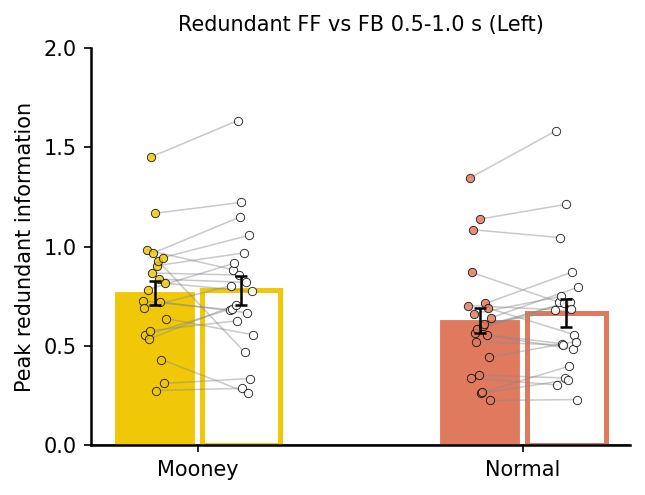

In [26]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Redundant FF vs FB 0.5-1.0 s (Left)', 'ylabel': 'Peak redundant information', 'hemisphere': 'Left', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.7251201204933446, 0.6927175974005051, 0.5544440980916523, 0.9833371877304722, 0.7834947341544707, 0.5341938802926964, 0.5767514675480181, 1.450612849050035, 0.8669369020393716, 0.968148414189329, 1.167044236890226, 0.27601264870052356, 0.9038839945833183, 0.92831167915987, 0.8355475210434892, 0.7214755807337921, 0.43181956571404334, 0.9438826652770999, 0.31188476192839754, 0.8156556773201736, 0.6379914744027391]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.682154865589702, 0.8035984522826407, 0.6883202663968677, 0.8830826865292882, 0.9164110104446773, 0.7071580686528772, 0.6266173205920976, 1.6336851741816651, 0.8566681530742568, 1.1487911480278485, 1.222076354102889, 0.28729250420321595, 0.9677768024473622, 0.46921657341587086, 0.8201189819058649, 0.6670925203854675, 0.2636197131854542, 1.0567210400222438, 0.33644611023927007, 0.7743058741229396, 0.5567372161235516]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.7032939925241194, 1.343703724512166, 0.3385779634290068, 0.8699539390486724, 1.0844594282457778, 0.6623776658594807, 0.5637184148767859, 0.5208779930530686, 0.584238099857677, 0.3537636485238593, 1.137875896656373, 0.26201319634515774, 0.2661946164949402, 0.6003181598862939, 0.6107294952730415, 0.7137771290920698, 0.554305228074308, 0.6910697743416286, 0.44372261722824086, 0.22622559722086183, 0.6418698320562153]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.6826387221131832, 1.5829123998457264, 0.30400613184645287, 0.7207492554338297, 1.0453225827177683, 0.7491242081339594, 0.5115540814935151, 0.5051799100131342, 0.7145517816089264, 0.33910171259709665, 1.2126341723839884, 0.32955758806392815, 0.3977065171129672, 0.7209572451428501, 0.6853118740281756, 0.871775267399845, 0.48449781471310416, 0.556644173629199, 0.5217857816277778, 0.23067322958641318, 0.7952230990848725]}], 'yticks': [0.0, 0.5, 1.0,1.5,2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 10: Redundant FF vs FB 0.5-1.0 s (Right)
Raw values embedded: 84

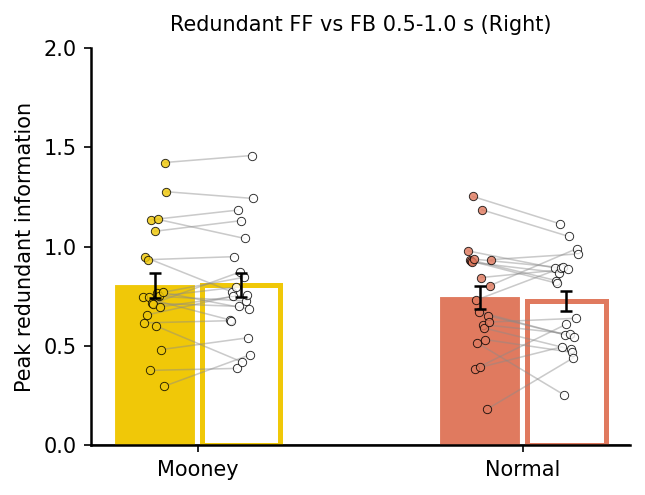

In [29]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Redundant FF vs FB 0.5-1.0 s (Right)', 'ylabel': 'Peak redundant information', 'hemisphere': 'Right', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.7442619467173304, 0.6161213308788143, 0.9451838182953857, 0.6557885997210872, 0.9339256863139624, 0.744274560333863, 0.3771648770427743, 1.1347055526695253, 0.7149831674185068, 0.713562430538188, 1.0766160059764749, 0.6015771359220262, 0.764400794308807, 1.1365157720654073, 0.7495360762999093, 0.6968663529271417, 0.4820738062455584, 0.7694579833737675, 0.29669802799401473, 1.422559998527694, 1.2758798104714502]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.6310298087974407, 0.6274018109297961, 0.7714719530486586, 0.7509604598715329, 0.9491652563326969, 0.7952807919583437, 0.3873457776672409, 1.1833531277116407, 0.6991453458719373, 0.8722109588104386, 1.1302303485185414, 0.4186990103486493, 0.8449570788117899, 1.0406548438374692, 0.7264687889766092, 0.7580693037575446, 0.5413401462201832, 0.6849256275480726, 0.45628309895773383, 1.4576674110850811, 1.2418961507533064]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.9775818183666141, 0.9334920448472964, 0.9274914429371989, 0.9206767508464413, 1.2517509386931378, 0.9365691070687066, 0.38669768338090027, 0.7312398774740114, 0.5147312110803381, 0.6723142414606353, 0.3963850002142009, 0.8440645883167427, 1.1844603362957944, 0.607638145099737, 0.5900788515789883, 0.532085056561185, 0.18071685476563595, 0.6530396012668578, 0.6202478790845304, 0.8034604329823267, 0.9342778581908693]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.8916597236356432, 0.8289476056547697, 0.8148029947177601, 0.868809539725004, 1.1148489376267623, 0.89438637291457, 0.4956254610669376, 0.8959368676892772, 0.2535839757068277, 0.5553246149262054, 0.6100631018750137, 0.8862925785382036, 1.050748887071021, 0.5604554359153309, 0.48319255109787823, 0.4679015775405389, 0.4401778884027002, 0.5449967938374342, 0.6390977208712348, 0.9894289299301011, 0.9627927892099885]}], 'yticks': [0.0, 0.5, 1.0,1.5,2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 11: Redundant peak intensity 0.5-1.0 s
Raw values embedded: 84

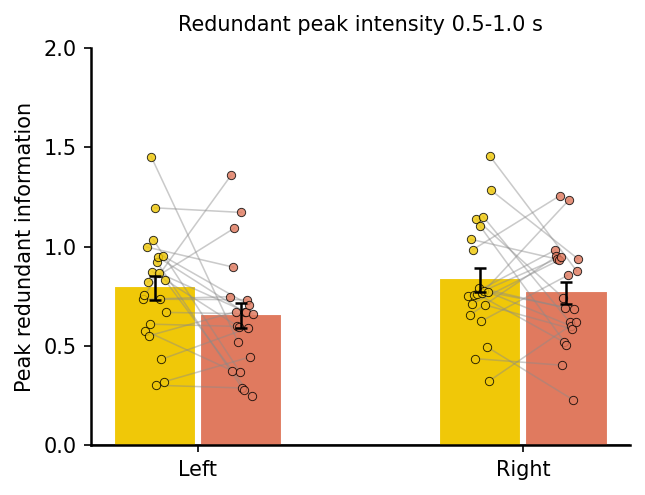

In [12]:
chart = {'plot_kind': 'condition_compare', 'title': 'Redundant peak intensity 0.5-1.0 s', 'ylabel': 'Peak redundant information', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.7351507915359253, 0.7549050060496588, 0.575999239107192, 0.9977405738124374, 0.8205122014379327, 0.5513414887915256, 0.6098561438603041, 1.4524813587221321, 0.874260692234561, 1.033876876700688, 1.1947167420761673, 0.30258956637640533, 0.9225803203184478, 0.9468777095948187, 0.8661692709420415, 0.7349898230684813, 0.432933127803811, 0.9538830381611573, 0.31954358554398143, 0.8320179342308741, 0.6689175320883904]}, {'category': 'Left', 'condition': 'Normal', 'raw': [0.7477551865013442, 1.3579561826052229, 0.3756129670289178, 0.8964918957254223, 1.0930535221533102, 0.672344871448651, 0.598529853748184, 0.5215986640408605, 0.5947023481605846, 0.3667674635950386, 1.171574929591161, 0.2887372076223329, 0.2785579050882413, 0.6691510969556593, 0.671336581089281, 0.7328110948305546, 0.5905337421374097, 0.7057176247478427, 0.4449481916244951, 0.24600626871207193, 0.6610318429990056]}, {'category': 'Right', 'condition': 'Mooney', 'raw': [0.7509395207599705, 0.6550196806749049, 1.0366172855882703, 0.7117316451817838, 0.9846130041415508, 0.7561913414939953, 0.436384903306746, 1.137095472447847, 0.7611564672885386, 0.7932100975543148, 1.104824284381115, 0.6240161415299311, 0.7647854674041995, 1.1505720625070557, 0.7788080250688031, 0.7056791769502916, 0.49658521298300007, 0.7720779442122011, 0.32305258423185196, 1.4536983034923372, 1.2830328642977702]}, {'category': 'Right', 'condition': 'Normal', 'raw': [0.98209303879802, 0.9503119071379719, 0.9363778938788266, 0.930673881807661, 1.2549948439379481, 0.9476057251414913, 0.40331624631339935, 0.7435235192507901, 0.5186147124001985, 0.6913544309389528, 0.5068426659627554, 0.8551423954886459, 1.2329382497896346, 0.6185720927662548, 0.6005195840903272, 0.5857104835479354, 0.2284016466618121, 0.6848092234476497, 0.6202478790845304, 0.8770371632711198, 0.9385203949313732]}], 'yticks': [0.0, 0.5, 1.0,1.5, 2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 12: Redundant peak latency 0.1-0.2 s
Raw values embedded: 84

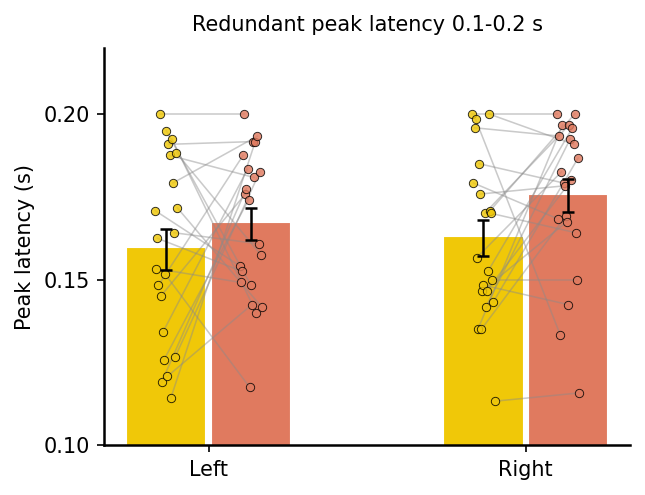

In [13]:
chart = {'plot_kind': 'condition_compare', 'title': 'Redundant peak latency 0.1-0.2 s', 'ylabel': 'Peak latency (s)', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.170833333333333, 0.153333333333333, 0.1625, 0.148333333333333, 0.2, 0.145, 0.119166666666666, 0.134166666666667, 0.125833333333333, 0.151666666666666, 0.195, 0.120833333333333, 0.190833333333333, 0.1875, 0.114166666666667, 0.1925, 0.179166666666666, 0.164166666666667, 0.126666666666666, 0.188333333333333, 0.171666666666666]}, {'category': 'Left', 'condition': 'Normal', 'raw': [0.154166666666667, 0.149166666666666, 0.1525, 0.1875, 0.2, 0.175833333333333, 0.1775, 0.183333333333333, 0.174166666666666, 0.1175, 0.148333333333333, 0.1425, 0.191666666666666, 0.180833333333333, 0.191666666666666, 0.14, 0.193333333333333, 0.160833333333333, 0.1825, 0.1575, 0.141666666666666]}, {'category': 'Right', 'condition': 'Mooney', 'raw': [0.2, 0.179166666666666, 0.195833333333333, 0.198333333333333, 0.156666666666667, 0.135, 0.185, 0.175833333333333, 0.135, 0.146666666666667, 0.148333333333333, 0.17, 0.141666666666666, 0.146666666666667, 0.1525, 0.1999999999, 0.170833333333333, 0.17, 0.15, 0.143333333333333, 0.113333333333333]}, {'category': 'Right', 'condition': 'Normal', 'raw': [0.2, 0.168333333333333, 0.193333333333333, 0.133333333333333, 0.1825, 0.196666666666667, 0.179166666666666, 0.178333333333333, 0.169166666666666, 0.1675, 0.1425, 0.196666666666667, 0.1925, 0.18, 0.195833333333333, 0.190833333333333, 0.2, 0.164166666666667, 0.15, 0.186666666666667, 0.115833333333333]}], 'yticks': [0.1, 0.15, 0.2], 'ylim': [0.1, 0.22]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 12b: Redundant peak information 0.1-0.2 s

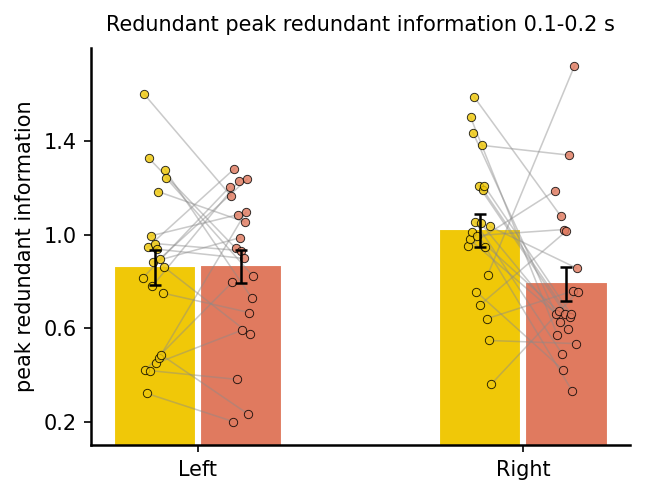

In [14]:
chart = {
    'plot_kind': 'condition_compare', 'title': 'Redundant peak redundant information 0.1-0.2 s', 'ylabel': 'peak redundant information', 'data': [{'category': 'Left', 'condition': 'Mooney', 'raw': [0.817231382,1.600408472,0.423131547,0.322518304,0.94722687,1.327384064,0.419782833,0.995819778,0.780601996,0.885126748,0.962935321,0.45022924,0.93887223,1.185086153,0.47386614,0.898830381,0.486710714,0.751311389,0.863659959,1.278636207,1.244038346]},
                                                                                                                                                  {'category': 'Left', 'condition': 'Normal', 'raw': [1.205693373,1.165869079,0.797107662,0.20171117,1.282803485,0.942919208,0.382253518,1.086198756,1.230820578,0.988043892,0.932160773,0.593329752,0.899230727,1.055270657,1.096755729,1.237180698,0.233881139,0.66792023,0.574083307,0.731597128,0.825178405]}, 
                                                                                                                                                  {'category': 'Right', 'condition': 'Mooney', 'raw': [0.952141327,0.980825731,1.502224769,1.010922042,1.436976752,1.589552121,1.054899503,0.756507942,0.997085073,1.209791977,0.699129649,1.049224899,1.382476821,1.191709568,1.209072052,0.947456773,0.641248531,0.829321715,0.548492277,1.035865356,0.361520431]},
                                                                                                                                                  {'category': 'Right', 'condition': 'Normal', 'raw': [1.188089112,0.662191445,0.571903251,0.67386256,0.627131094,1.080008963,0.492701207,0.422570725,1.022761184,0.662219717,1.016536686,0.599228979,1.340820423,0.64672835,0.660292627,0.33310679,0.76070302,1.721689743,0.535351824,0.857407773,0.757040771]}], 'yticks': [0.2,0.6,1.0,1.4], 'ylim': [0.1, 1.8]}
fig, ax, data = plot_chart(chart)
plt.show()



### Figure 13: Redundant FF vs FB 0.1-0.2 s (red network) (Left)
Raw values embedded: 84

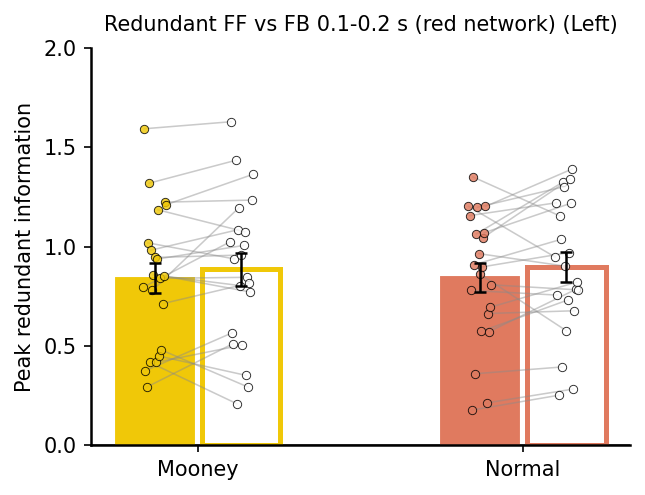

In [15]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Redundant FF vs FB 0.1-0.2 s (red network) (Left)', 'ylabel': 'Peak redundant information', 'hemisphere': 'Left', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.795254054655712, 1.59224401829255, 0.375796208913605, 0.293020545363125, 1.01878571346975, 1.31823112723059, 0.416982844399215, 0.982094134482496, 0.77899899133531, 0.858180439954292, 0.945116008573517, 0.417162330313858, 0.936911187715782, 1.1845233880529, 0.449119277903243, 0.840062176514811, 0.479909268032524, 0.712583931329324, 0.852494251254616, 1.22325513864251, 1.21011795057896]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [1.02332427400774, 1.627571976693, 0.566105397961125, 0.512251445036232, 0.937675264808544, 1.43336679304712, 0.209895739493967, 1.08439703417717, 1.19577988501891, 0.803653637012634, 0.957234668176415, 0.504786933407789, 1.00531921272584, 1.0743782441153, 0.352397086194893, 0.845268246887222, 0.293375809346242, 0.815573621934607, 0.771204282589422, 1.23361039471648, 1.36259751611463]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [1.20261040984155, 1.15559817976762, 0.779342342587751, 0.177478466330114, 1.34996717812121, 0.908829550736311, 0.360457099048203, 1.06333673032532, 1.19755337534999, 0.964549077253972, 0.861646851237953, 0.573023764771867, 0.897587182818569, 1.04504558173621, 1.06959911091065, 1.20146780194416, 0.213549383221196, 0.663299879806574, 0.571700555848008, 0.694609226457222, 0.80772166012615]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.947123724761789, 1.22004499437122, 0.755796527538053, 0.252099319631409, 1.15436840391666, 1.03572814700255, 0.394402140876763, 1.32432694272843, 1.30091753717101, 0.901315315190034, 0.576153778675752, 0.730862063754654, 0.969635624969849, 1.3391810386635, 1.21800123768812, 1.38987520492603, 0.283440272380098, 0.677079906037248, 0.784018084432498, 0.820840558746729, 0.781995169826441]}], 'yticks': [0.0, 0.5, 1.0,1.5, 2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


### Figure 14: Redundant FF vs FB 0.1-0.2 s (red network) (Right)
Raw values embedded: 84

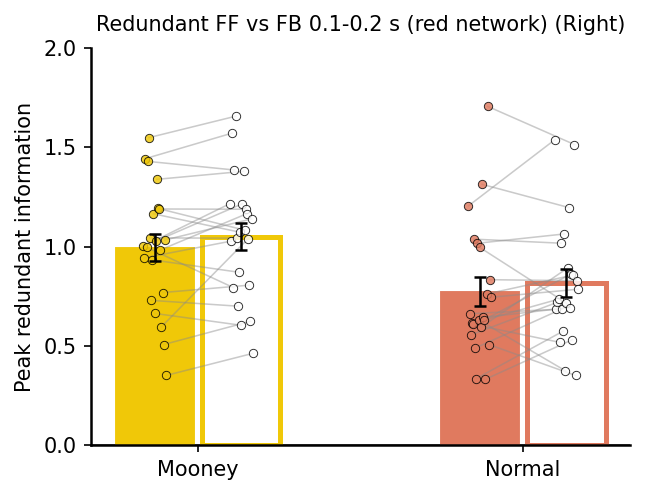

In [16]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Redundant FF vs FB 0.1-0.2 s (red network) (Right)', 'ylabel': 'Peak redundant information', 'hemisphere': 'Right', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [1.00122170177163, 0.943091764100077, 1.44219982772838, 0.996138225940428, 1.4282690515015, 1.5475521123621, 1.04349462182078, 0.729352001820634, 0.933051040447354, 1.16475509444387, 0.663878649347089, 1.02731142171226, 1.33796177429808, 1.19163986669376, 1.18888366485948, 0.982744832879707, 0.596194380712526, 0.768648115789371, 0.507164407942412, 1.03279725548961, 0.351643180317267]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [1.21564379526272, 1.02720047405004, 1.57037847909492, 0.793744029401766, 1.38488021019033, 1.65525426274794, 1.04212196468498, 0.700154834040698, 0.870677621766275, 1.07179784559922, 0.60393113938217, 1.21530741512947, 1.37814878893549, 1.08237367596705, 1.18747395687099, 1.16543784032412, 1.03927691126611, 0.805836139316872, 0.623878723328159, 1.13873507775218, 0.462527163433043]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [1.20417123121462, 0.662191445178044, 0.555363784640173, 0.613091627821664, 0.608563101090945, 1.03712169775653, 0.489586639154219, 0.33646501843626, 1.01657167637485, 0.630994510179593, 0.99557051328261, 0.594066887721013, 1.31288364843933, 0.643527517804693, 0.631914115938071, 0.332793286359822, 0.761263676746716, 1.70466061239332, 0.507176365241148, 0.833315749703409, 0.744985367138927]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [1.5382049774905, 0.684398284251691, 0.719779624604892, 0.735357734265315, 0.51842448012812, 1.01686438447266, 0.686114795776345, 0.574429106774237, 1.06319568676646, 0.375580252338761, 0.71548465402848, 0.892116586923286, 1.19614359862375, 0.693360624509992, 0.861629903362265, 0.531095130820486, 0.856778820472196, 1.51288328209386, 0.35185891314729, 0.827974821446994, 0.78531163615365]}], 'yticks': [0.0, 0.5, 1.0,1.5, 2.0], 'ylim': [0.0, 2.0]}
fig, ax, data = plot_chart(chart)
plt.show()


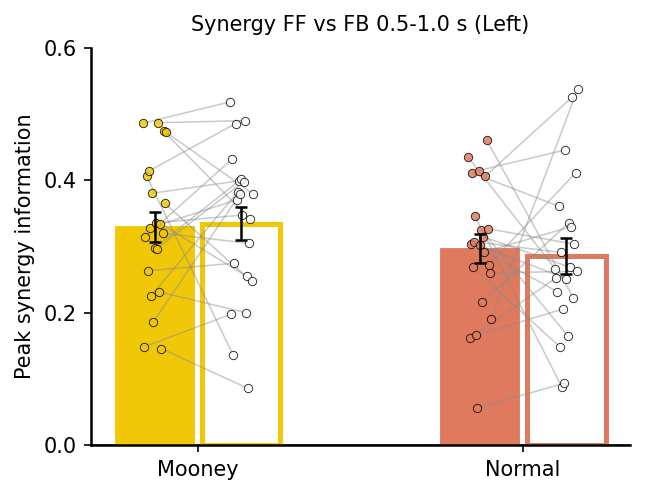

In [17]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Synergy FF vs FB 0.5-1.0 s (Left)', 'ylabel': 'Peak synergy information', 'hemisphere': 'Left', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.486121715,0.148763072,0.315119374,0.406265047,0.263456587,0.413978713,0.328049077,0.225797234,0.380392259,0.186645197,0.298041622,0.335656591,0.296624031,0.486826859,0.231619592,0.334625335,0.145934082,0.320159516,0.473888487,0.365007361,0.472574941]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.518221327,0.197912054,0.431995773,0.135763715,0.274910051,0.485444655,0.370581041,0.382476878,0.399200903,0.379343468,0.401778894,0.347565091,0.397793109,0.489903239,0.200232374,0.254972097,0.085923198,0.304810772,0.34100678,0.247528143,0.379812326]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.434331375,0.161435596,0.304227827,0.411428124,0.268808697,0.307349236,0.345336985,0.166515122,0.056480594,0.414592917,0.30165746,0.325546023,0.215593566,0.314795882,0.291822043,0.406397438,0.460793114,0.326909335,0.27246947,0.260164605,0.191192378]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.266584672,0.252978709,0.231743472,0.360923235,0.14880994,0.291117142,0.087886481,0.205788803,0.093798308,0.445819638,0.251414132,0.165639417,0.335776054,0.26877333,0.329908611,0.525508886,0.222837026,0.303579225,0.411133541,0.262738593,0.538224472]}], 'yticks': [0.0, 0.2, 0.4, 0.6], 'ylim': [0.0, 0.6]}
fig, ax, data = plot_chart(chart)
plt.show()

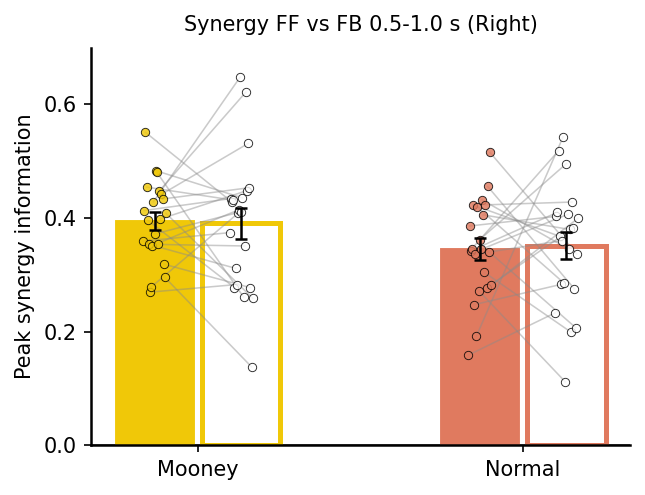

In [18]:
chart = {'plot_kind': 'ff_fb_compare', 'title': 'Synergy FF vs FB 0.5-1.0 s (Right)', 'ylabel': 'Peak synergy information', 'hemisphere': 'Left', 'data': [{'condition': 'Mooney', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.359565565,0.413406838,0.551045406,0.454578045,0.396285727,0.353864611,0.269778608,0.278669693,0.351746997,0.42877652,0.37213461,0.483636429,0.480669999,0.353740084,0.447492574,0.398468553,0.441703733,0.433692269,0.319073351,0.295747163,0.408522613]}, {'condition': 'Mooney', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.374545485,0.434474589,0.427910063,0.431668982,0.277859093,0.311684329,0.283146046,0.408240939,0.414890907,0.648193517,0.411334008,0.435542343,0.261176605,0.351008898,0.621723824,0.448429519,0.531402872,0.453527106,0.277638224,0.138308902,0.2590317]}, {'condition': 'Normal', 'direction': 'V1/OFA -> FFA', 'style': 'feedforward', 'raw': [0.15900713,0.386147241,0.342406215,0.346026321,0.423312561,0.247721581,0.336499485,0.191973576,0.419398432,0.272478649,0.362180656,0.344858243,0.432188023,0.405744842,0.304531335,0.423343731,0.276969065,0.455702412,0.340988744,0.515622489,0.281818521]}, {'condition': 'Normal', 'direction': 'FFA/OFA -> V1', 'style': 'feedback', 'raw': [0.233299749,0.403123445,0.410205746,0.518419647,0.368005361,0.283275615,0.3604542,0.543058587,0.285380081,0.111795856,0.496094997,0.406539154,0.345390914,0.380012755,0.199313301,0.428308222,0.382825291,0.27538767,0.207408635,0.336898259,0.399498751]}], 'yticks': [0.0, 0.2, 0.4, 0.6], 'ylim': [0.0, 0.7]}
fig, ax, data = plot_chart(chart)
plt.show()